In [ ]:
import numpy as np
from PIL import Image, ImageFilter
import matplotlib.pyplot as plt

In [ ]:
image_path = "/content/animal.jpg"

In [ ]:
img = Image.open(image_path).convert("RGB")

In [ ]:
img_array = np.array(img).astype(np.float32)

In [ ]:
gray = (
    0.299 * img_array[:, :, 0] +
    0.587 * img_array[:, :, 1] +
    0.114 * img_array[:, :, 2]
)

gray = (gray - gray.min()) / (gray.max() - gray.min()) * 255

In [ ]:
inverted = 255 - gray

In [ ]:
inverted_pil = Image.fromarray(inverted.astype(np.uint8))


blurred_pil = inverted_pil.filter(ImageFilter.GaussianBlur(radius=8))


blurred = np.array(blurred_pil).astype(np.float32)

In [ ]:
def dodge_blend(gray, blurred):

    result = gray * 255 / (255 - blurred + 1e-5)

    result = np.clip(result, 0, 255)

    return result

sketch = dodge_blend(gray, blurred)

In [ ]:
contrast = 1.3

sketch = (sketch - 128) * contrast + 128

# Slight darkening
sketch = sketch - 10

sketch = np.clip(sketch, 0, 255).astype(np.uint8)

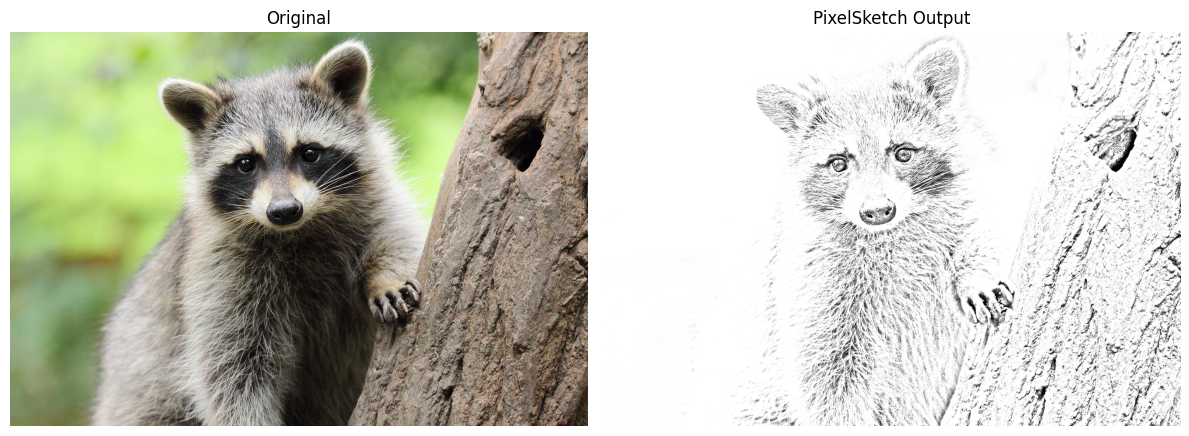

In [ ]:
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(img)
plt.axis("off")

plt.subplot(1,2,2)
plt.title("PixelSketch Output")
plt.imshow(sketch, cmap="gray")
plt.axis("off")

plt.tight_layout()
plt.show()
